SHAP 개념 설명
🔹 SHAP이란?

SHAP = SHapley Additive exPlanations

“각 feature가 예측값에 얼마나 기여했는지”를 수학적으로 공정하게 나누는 방법

게임 이론에서의 Shapley value를 머신러닝 모델 설명에 적용한 것

🔹 왜 쓰는가?

개별 예측(로컬 수준) 설명 가능

“이 사람의 예측이 양성 0.93이 된 이유는 반지름, 면적, concavity 때문에 그렇다.”를 숫자로 설명 가능

**전체적으로 어떤 feature가 중요한지(글로벌)**도 볼 수 있음

summary_plot, bar plot 등으로 feature importance를 시각화

모델에 상관 없이(모델 불문) 적용 가능

트리 계열(XGBoost, LightGBM, RandomForest…)에 특히 빠르고 정확한 전용 알고리즘 제공(TreeExplainer)

🔹 직관적 이해

모델을 하나의 협동 게임이라고 보고,

각 feature를 플레이어라고 생각한다.

특정 데이터 포인트에 대해 예측 값이 나왔을 때,
“기본값(예: 평균 예측값)에서 출발하여 각 feature가 조금씩 기여한 값의 합 = 최종 예측”으로 본다.

이때, “각 feature가 얼마만큼 기여했는지”를 계산한 값이 SHAP value.

In [15]:
! pip install shap

   ---------------------------------------- 547.2/547.2 kB 6.1 MB/s  0:00:00



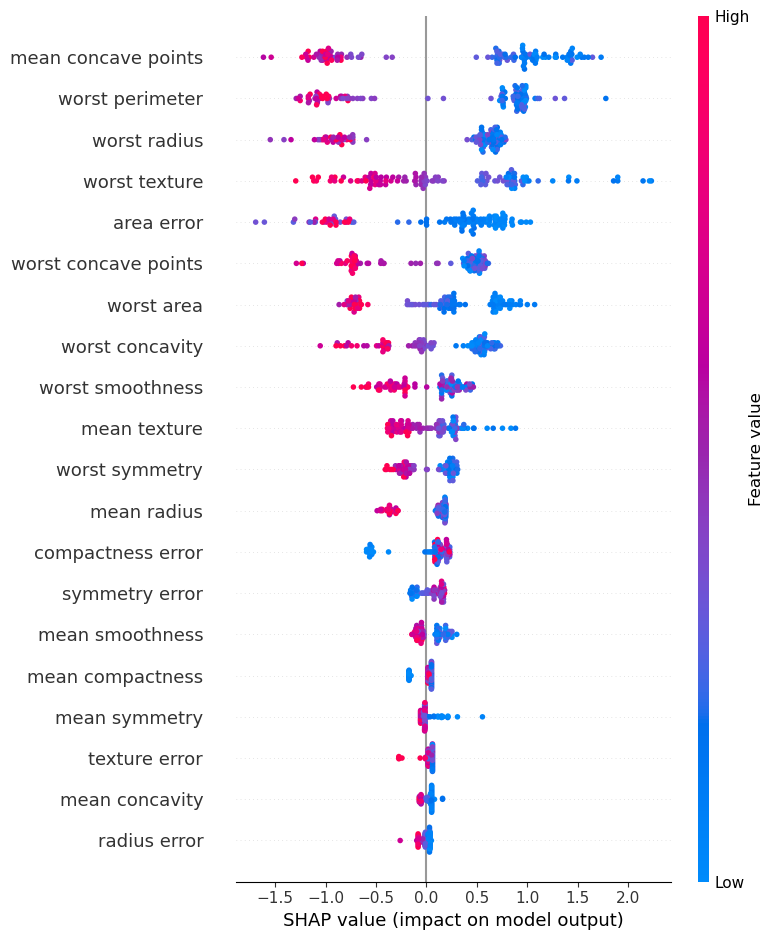

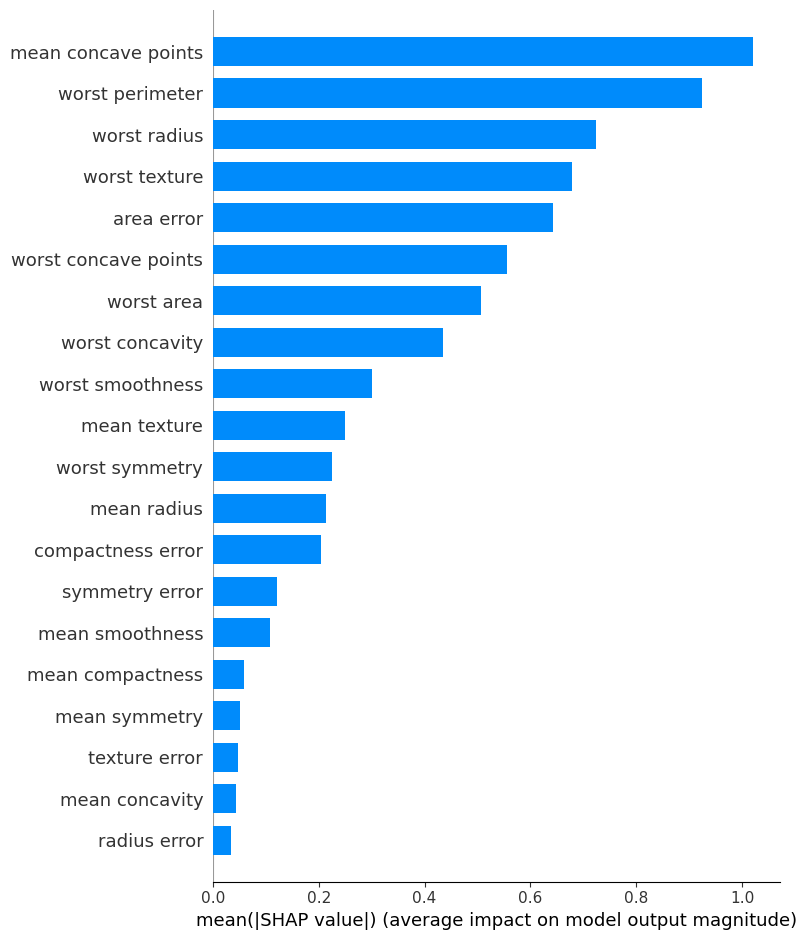

In [16]:
# ===== 1. SHAP 라이브러리 불러오기 및 기본 설정 =====

import shap
# 모델 해석(Explainability)을 위해 SHAP 라이브러리를 불러온다.
# SHAP는 각 feature가 예측에 얼마나 기여했는지를 정량적으로 계산하는 도구이다.

shap.__version__
# 설치된 SHAP 버전을 확인하여 사용 중인 환경 정보를 파악할 수 있다.
# (필수는 아니지만, 버전 차이에 따른 API 차이를 확인할 때 유용하다.)

shap.initjs()
# 주피터 노트북 환경에서 대화형(interactive) 플롯을 보기 위해 자바스크립트 기반 설정을 초기화한다.
# 특히 summary_plot 등의 시각화를 웹 기반으로 예쁘게 보여주는 역할을 한다.


# ===== 2. TreeExplainer 생성 (XGBoost 모델용) =====

explainer = shap.TreeExplainer(xgb_model)
# XGBoost, LightGBM 같은 트리 기반 모델에 최적화된 TreeExplainer 객체를 생성한다.
# 이 explainer는 학습된 xgb_model을 분석하여 각 feature의 SHAP value를 계산한다.


# ===== 3. 해석에 사용할 입력 데이터 준비 =====

X_test_sample = X_test.copy()
# 테스트 데이터 전체를 복사하여 SHAP 계산에 사용할 입력 데이터로 만든다.
# 보통 X_test 전체를 사용하거나, 일부 샘플을 추려서 사용한다.

# (선택) 필요시 numpy 배열로 변환할 수도 있지만,
# SHAP는 DataFrame을 그대로 넣어도 컬럼명을 인식하여 시각화에 활용해준다.
# X_test_array = X_test_sample.values  # 이렇게 변환도 가능하다.


# ===== 4. SHAP 값 계산 =====

shap_values = explainer.shap_values(X_test_sample)
# explainer를 이용해 X_test_sample에 대한 SHAP 값을 계산한다.
# 반환되는 shap_values는 '각 샘플, 각 feature가 예측값에 기여한 정도'를 담고 있다.

# 이진 분류의 경우 shap_values가 리스트 형태로 반환되는 버전도 있으므로 아래와 같이 처리할 수 있다.
if isinstance(shap_values, list):
    # 리스트로 반환되면 클래스별 SHAP 값이 들어 있으므로,
    # 일반적으로 "양성(1) 클래스" 기준으로 두 번째 요소를 사용한다.
    shap_values_to_use = shap_values[1]
else:
    # 배열 형태로 반환되면 그대로 사용한다.
    shap_values_to_use = shap_values


# ===== 5. 전체적인 Feature 중요도(글로벌) 시각화: Summary Plot =====

shap.summary_plot(
    shap_values_to_use,      # 각 샘플×피처에 대한 SHAP 값
    X_test_sample,           # 원본 입력 데이터 (컬럼명 포함)
    plot_type="dot"          # 도트 형태의 요약 플롯(기본값)으로 설정한다.
)
# summary_plot은 전체 데이터에 대해 feature별 SHAP 분포를 한 번에 보여준다.
# x축은 SHAP 값(양수/음수: 예측을 증가/감소시키는 방향), y축은 feature 이름이다.
# 색깔은 해당 feature의 원래 값이 높은지/낮은지 표시해준다(보통 빨강=값 큼, 파랑=값 작음).


# ===== 6. Feature 중요도를 막대 그래프로 보는 bar plot =====

shap.summary_plot(
    shap_values_to_use,      # SHAP 값
    X_test_sample,           # 입력 데이터
    plot_type="bar"          # bar 타입을 선택하여 평균 절대 SHAP 값을 기준으로 중요도를 그린다.
)
# plot_type="bar"를 사용하면 각 feature의 "평균 절대 SHAP 값"을 기준으로
# 전반적인 중요도를 한 눈에 비교할 수 있다.
# 값이 클수록 모델 예측에 큰 영향을 미친다는 의미이다.


# ===== 7. 개별 샘플에 대한 로컬 설명: force_plot (선택) =====

# 특정 인덱스의 한 샘플을 선택하여 해당 예측의 이유를 구체적으로 보고 싶을 때 사용한다.
idx = 0
# 테스트 데이터의 첫 번째 샘플을 선택한다.

shap.force_plot(
    explainer.expected_value,     # 기준값(모든 샘플에 대한 평균 예측값)을 전달한다.
    shap_values_to_use[idx, :],   # 선택한 샘플의 각 feature별 SHAP 값 벡터를 전달한다.
    X_test_sample.iloc[idx, :]    # 선택한 샘플의 원본 feature 값들을 전달한다.
)
# force_plot은 한 개의 예측에 대해
# "기본값에서 시작해서 각 feature가 예측을 올리거나 내리는 방향으로 얼마나 밀어냈는지"
# 시각적으로 보여주는 플롯이다.
# 빨간색은 예측값을 올리는 방향(예: 양성 가능성을 높이는 방향), 파란색은 낮추는 방향을 의미한다.


✅ 1. 그래프 전체 구조 이해

이 SHAP summary dot plot은 다음 요소로 구성됩니다:

Y축: Feature 목록 (중요한 순서대로 정렬됨)

X축: SHAP value
→ 예측 결과에 대한 feature의 “기여도”

양수(오른쪽): 해당 feature가 양성(benign) 쪽으로 확률을 증가시킴

음수(왼쪽): 해당 feature가 악성(malignant) 쪽으로 확률을 증가시킴

색깔: 원래 feature 값의 크기

빨강 = 큰 값

파랑 = 작은 값

점 하나 = 테스트 데이터 1개의 feature 값

즉,
각 점은 ‘특정 샘플의 그 feature가 예측을 어느 방향으로 얼마나 밀었는지’ 나타내는 것입니다.

✅ 2. X축: SHAP Value 의미
SHAP 값 방향	해석
양수(+)	모델이 양성(1) 쪽으로 예측하도록 기여
음수(-)	모델이 악성(0) 쪽으로 예측하도록 기여

예:
SHAP = +1.0 이면
→ 이 feature가 “그 샘플을 양성이라고 판단하도록 1.0만큼 밀어줌”

✅ 3. 색: Feature 원래 값

빨간색 (High) → 해당 feature의 값이 높다

파란색 (Low) → 해당 feature의 값이 낮다

보라색 → 중간값

이 색은 feature의 원래 값이 높을 때 예측에 어떤 영향을 주는지 해석하는 데 매우 중요함.

✅ 4. 주요 Feature 해석 (중요도 순으로 분석)

아래 해석은 그래프에 나타난 패턴을 기반으로 SHAP 방식으로 “모델이 실제로 어떻게 판단하는지”를 설명하는 것입니다.

🔹 1) mean concave points

가장 중요도가 높은 feature

**빨간 점(값이 높은 샘플)**은 대부분 오른쪽(+ 방향) → 양성 확률 증가

파란 점(값 낮음)은 왼쪽(음수)

➡ mean concave points 값이 클수록 양성으로 판단될 가능성이 증가
(특정 데이터셋에서는 concave points가 클 때 benign일 수도 있음. 데이터 특성에 따라 반대인 경우도 있음)

🔹 2) worst perimeter

값이 클수록(빨간색) → 오른쪽(양수)

값이 작으면(파란색) → 왼쪽(음수)

➡ 둘레가 긴 종양은 양성 쪽으로 기여하는 패턴
(이 부분은 데이터셋 특성에 따라 benign일 때 둘레가 크다는 경향을 모델이 학습한 것)

🔹 3) worst radius

worst radius가 큰 샘플(빨간)이 대부분 양수

작은 샘플(파란)은 음수

➡ 반지름이 큰 경우 모델은 양성(1) 쪽으로 판단하는 경향

🔹 4) worst texture

worst texture 높은 값(빨강)도 양수 방향으로 기여

낮은 값(파랑)은 대체로 음수

➡ texture(표면 불균일성)가 클수록 양성 쪽으로 영향

🔹 5) area error

값이 큰 경우(빨강)는 오른쪽(양수)

작은 값(파랑)은 왼쪽

➡ 면적 변동성이 크면 양성으로 기여

🔹 전반적인 패턴

대부분의 top feature에서 공통적으로 보이는 현상:

빨간 점(high value) → 양수 방향

파란 점(low value) → 음수 방향

즉,

해당 데이터셋에서는 feature 값이 클수록 양성(benign)으로 분류하는 패턴을 XGBoost가 학습함

이는 위스콘신 데이터에서 라벨(0=악성, 1=양성)의 분포 특성 및 샘플들의 실제 값에 의해 결정됩니다.

✅ 5. 하위 중요도 Feature 해석
mean concavity, mean compactness 등

점들이 중심(0 근처)에 밀집 → 영향이 크지 않음

SHAP 값의 절대값이 작다 → 예측을 크게 바꾸지는 않음

radius error, texture error 등

SHAP 분포가 거의 0 근처

모델이 거의 사용하지 않는 특징

✅ 6. SHAP summary plot 종합 해석 (최종 요약)

mean concave points, worst perimeter, worst radius 등이 예측에 가장 큰 영향

feature 값이 높을수록(빨간색), 대부분 양성(1) 방향으로 기여

feature 값이 낮을수록(파란색), 대부분 악성(0) 방향으로 기여

하위 feature들은 SHAP 값이 작아 예측에 별 영향 없음

모델은 “종양 크기 / 모양의 오목함 / 둘레 / 반경”과 같은 특징에 가장 의존함

SHAP plot을 통해

글로벌: 전체 feature 중요도

로컬: 각 샘플이 어떻게 판단되었는지
를 동시에 잘 보여줌